# MSCS 634 Lab 2: K-Nearest Neighbors and Radius Neighbors Classification on the Wine Dataset

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 2 - K-Nearest Neighbors and Radius Neighbors Classification on the Wine Dataset

## Step 1: Load and Prepare the Dataset

This section loads the Wine dataset from `sklearn`, reviews the feature columns, checks the class distribution, and creates an 80% training / 20% testing split. A stratified split is used so the train and test sets preserve the three wine-class proportions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

wine_df = X.copy()
wine_df["target"] = y
wine_df["class_name"] = y.map(dict(enumerate(wine.target_names)))

print(f"Dataset shape: {X.shape[0]} rows and {X.shape[1]} features")
print("Target classes:", list(wine.target_names))
wine_df.head()

Dataset shape: 178 rows and 13 features
Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


In [4]:
class_distribution = (
    wine_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)
class_distribution

,class_name,count
0,class_1,71
1,class_0,59
2,class_2,48


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print("Training class counts:")
print(y_train.map(dict(enumerate(wine.target_names))).value_counts().sort_index())
print("\nTesting class counts:")
print(y_test.map(dict(enumerate(wine.target_names))).value_counts().sort_index())

Training set: 142 rows
Testing set: 36 rows
Training class counts:
target
class_0    47
class_1    57
class_2    38
Name: count, dtype: int64

Testing class counts:
target
class_0    12
class_1    14
class_2    10
Name: count, dtype: int64


### Dataset Exploration Interpretation

The Wine dataset contains 178 records and 13 numeric chemical-property features. The class distribution is not perfectly even, with class 1 containing the most records and class 2 containing the fewest. Because of this imbalance, the split uses `stratify=y` so that the training and testing sets keep approximately the same class proportions. The feature summary also shows that variables are measured on very different scales, especially `proline` compared with features such as `hue` and `nonflavanoid_phenols`. This scale difference is important because neighbor-based models use distance calculations.

## Step 2: Implement K-Nearest Neighbors (KNN)

The KNN classifier is trained with `k` values of 1, 5, 11, 15, and 21. Accuracy is recorded for each model on the same test set.

In [6]:
k_values = [1, 5, 11, 15, 21]
knn_results = []
knn_models = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    knn_models[k] = model
    knn_results.append({"k": k, "accuracy": accuracy})

knn_results_df = pd.DataFrame(knn_results)
knn_results_df

,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


### KNN Results Interpretation

The KNN results show that `k=1` produced the lowest KNN accuracy, while `k=5`, `k=11`, `k=15`, and `k=21` produced the same higher accuracy. This suggests that using only one neighbor made the model more sensitive to individual observations in the training set. Increasing `k` helped smooth the decision boundary and gave more stable predictions, but accuracy did not continue improving after `k=5` for this train-test split.

## Step 3: Implement Radius Neighbors (RNN)

The Radius Neighbors classifier is trained with radius values of 350, 400, 450, 500, 550, and 600. The `outlier_label="most_frequent"` setting prevents prediction errors if a test sample has no neighbors inside the selected radius.

In [7]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []
rnn_models = {}

for radius in radius_values:
    model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label="most_frequent"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    rnn_models[radius] = model
    rnn_results.append({"radius": radius, "accuracy": accuracy})

rnn_results_df = pd.DataFrame(rnn_results)
rnn_results_df

,radius,accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


### RNN Results Interpretation

The Radius Neighbors model performed best at the smallest tested radius, 350. As the radius increased, accuracy declined because larger neighborhoods allowed more distant samples to affect each prediction. This indicates that the tested radius values became too broad for the structure of this dataset. RNN is especially sensitive to feature scale, so the unscaled Wine features make the radius parameter difficult to tune precisely.

## Step 4: Visualize and Compare Results

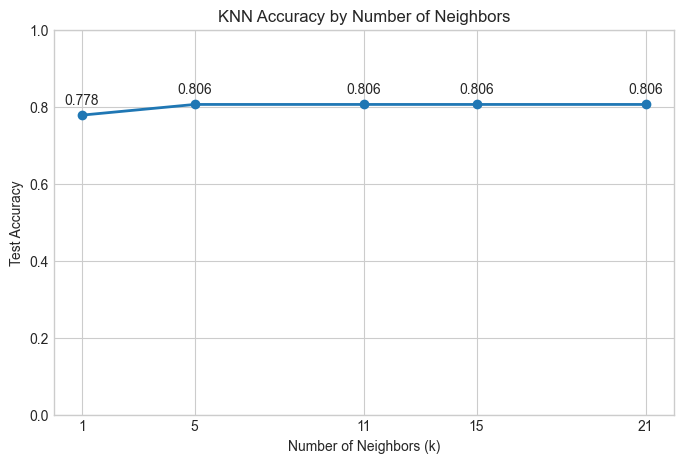

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_results_df["k"], knn_results_df["accuracy"], marker="o", linewidth=2, color="#1f77b4")
ax.set_title("KNN Accuracy by Number of Neighbors")
ax.set_xlabel("Number of Neighbors (k)")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(k_values)
ax.set_ylim(0, 1)
for row in knn_results_df.itertuples(index=False):
    ax.annotate(f"{row.accuracy:.3f}", (row.k, row.accuracy), textcoords="offset points", xytext=(0, 8), ha="center")
plt.show()

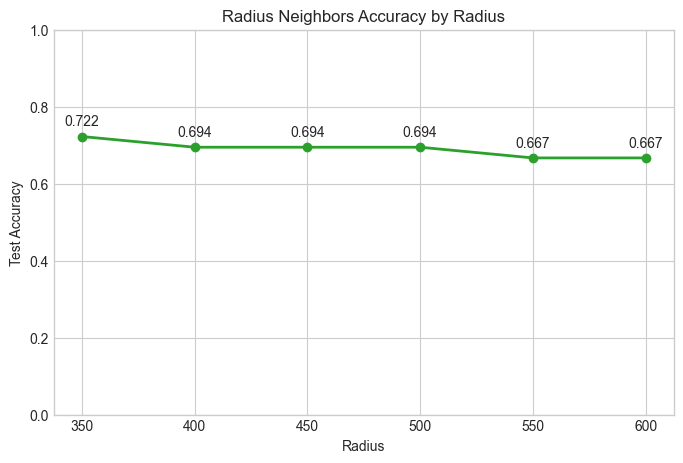

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rnn_results_df["radius"], rnn_results_df["accuracy"], marker="o", linewidth=2, color="#2ca02c")
ax.set_title("Radius Neighbors Accuracy by Radius")
ax.set_xlabel("Radius")
ax.set_ylabel("Test Accuracy")
ax.set_xticks(radius_values)
ax.set_ylim(0, 1)
for row in rnn_results_df.itertuples(index=False):
    ax.annotate(f"{row.accuracy:.3f}", (row.radius, row.accuracy), textcoords="offset points", xytext=(0, 8), ha="center")
plt.show()

In [10]:
best_knn = knn_results_df.loc[knn_results_df["accuracy"].idxmax()]
best_rnn = rnn_results_df.loc[rnn_results_df["accuracy"].idxmax()]

comparison = pd.DataFrame([
    {"model": "KNN", "best_parameter": f"k={int(best_knn['k'])}", "best_accuracy": best_knn["accuracy"]},
    {"model": "RNN", "best_parameter": f"radius={int(best_rnn['radius'])}", "best_accuracy": best_rnn["accuracy"]},
])
comparison

,model,best_parameter,best_accuracy
0,KNN,k=5,0.805556
1,RNN,radius=350,0.722222


### Plot Interpretation

The KNN trend plot shows a small improvement from `k=1` to `k=5`, followed by a flat accuracy pattern through `k=21`. The RNN trend plot shows the opposite behavior: accuracy is highest at radius 350 and gradually drops as the radius grows. Comparing the two plots, KNN is more reliable for this experiment because it maintains higher accuracy across several parameter choices, while RNN depends more heavily on selecting an appropriate radius.

In [11]:
best_knn_model = knn_models[int(best_knn["k"])]
best_knn_predictions = best_knn_model.predict(X_test)

print(f"Best KNN model: k={int(best_knn['k'])}")
print("Confusion matrix:")
print(confusion_matrix(y_test, best_knn_predictions))
print("\nClassification report:")
print(classification_report(y_test, best_knn_predictions, target_names=wine.target_names))

Best KNN model: k=5
Confusion matrix:
[[12  0  0]
 [ 0 10  4]
 [ 0  3  7]]

Classification report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.77      0.71      0.74        14
     class_2       0.64      0.70      0.67        10

    accuracy                           0.81        36
   macro avg       0.80      0.80      0.80        36
weighted avg       0.81      0.81      0.81        36



## Final Observations

- KNN demonstrated the highest overall performance in this experiment. The maximum KNN accuracy was 0.806, achieved by `k=5`, `k=11`, `k=15`, and `k=21`. The `k=1` model scored 0.778, which indicates that relying on a single nearest neighbor made the model more sensitive to individual local data points.
- RNN accuracy decreased as the radius parameter increased. The best RNN result was 0.722 at radius 350. Larger radii included more distant observations in each neighborhood, which reduced accuracy to 0.667 at radii 550 and 600.
- The confusion matrix for the best KNN model shows that class 0 was classified perfectly in the test set, while most errors occurred between class 1 and class 2. This suggests those two classes are closer together under the original feature distances.
- KNN is preferable for this dataset and parameter range because it produced higher accuracy and was less sensitive to parameter changes. RNN can be useful when a meaningful distance radius is known or when local density is important, but this experiment shows that radius selection must be tuned carefully.
- Feature scaling was not applied because the assigned RNN radius values were based on the original Wine feature ranges. If standardized features were used, both KNN and RNN should be rerun because distance calculations and optimal parameter values would change.